# Phase 9  -  Gradient Boosting (XGBoost + LightGBM)

**Research questions addressed:**
- **Q1** (multi-class): Can defence system repertoire classify species?
  How does gradient boosting compare to Random Forest?
- **Q2** (binary, per species): Can defence profile predict high-ARG burden?

**Methodology highlights:**
- All evaluation uses `StratifiedGroupKFold` (5-fold, groups = Mash phylogroups from NB04)
- Feature set: 359 dp_* features (367 total, 8 taxonomic markers removed at spec_score ≥ 0.70)
- Hyperparameter tuning: GridSearchCV (fixed n_estimators) then early stopping to set n_estimators
- Statistical comparison vs RF: McNemar's test on pooled per-genome predictions (n=3,335)
- Calibration: reliability diagram + Brier score for XGBoost and LightGBM
- Manuscript McNemar comparison uses `run_mcnemar_367.py`, not this notebook directly


## Section 1  -  Imports and configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from IPython.display import display, Image as IPImage
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import (
    balanced_accuracy_score, f1_score,
    confusion_matrix, roc_auc_score, brier_score_loss,
)
from sklearn.calibration import calibration_curve, CalibrationDisplay
from sklearn.dummy import DummyClassifier
import joblib

from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier

ROOT  = Path("..")
PROC  = ROOT / "data" / "processed"
RES   = ROOT / "results"
FIG   = RES / "figures" / "gb"
FIG.mkdir(parents=True, exist_ok=True)
(RES / "models").mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_SPLITS     = 5
N_BOOT       = 2000

print(f"XGBoost version: {__import__('xgboost').__version__}")
print(f"LightGBM version: {lgb.__version__}")
print("Imports OK.")

XGBoost version: 3.2.0
LightGBM version: 4.6.0
Imports OK.


## Section 2  -  Load data and feature selection

Identical 359-feature set from NB05–NB06 (367 dp_* columns, 8 taxonomic markers removed
at spec_score >= 0.70). Using the same features across all models is non-negotiable for
valid performance comparison within this notebook's 367-feature analysis.

In [2]:
fm      = pd.read_parquet(PROC / "feature_matrix_3335.parquet")
dp_cols    = sorted([c for c in fm.columns if c.startswith("dp_")])
sp_prev    = fm.groupby("species")[dp_cols].mean()
spec_score = sp_prev.std() / 0.5
markers    = spec_score[spec_score >= 0.70].index.tolist()
FEAT_COLS  = [c for c in dp_cols if c not in markers]

y_q1_str = fm["species"].to_numpy(dtype=str)
groups   = fm["phylogroup"].to_numpy(dtype=str)
X        = fm[FEAT_COLS].to_numpy(dtype=float)

# Integer-encode labels: XGBoost requires integer class labels (or sklearn auto-handles it,
# but explicit encoding avoids edge cases across XGBoost versions)
le = LabelEncoder()
y_q1 = le.fit_transform(y_q1_str)   # 0..5
CLASSES = list(le.classes_)         # alphabetical: abaumannii, ecloaceae, ...

print(f"Feature matrix: {X.shape[0]} genomes x {X.shape[1]} features")
print(f"Classes ({len(CLASSES)}): {CLASSES}")
print(f"Labels encoded: {dict(zip(CLASSES, le.transform(CLASSES)))}")
print(f"Markers removed: {len(markers)}")


Feature matrix: 3335 genomes x 359 features
Classes (6): [np.str_('abaumannii'), np.str_('ecloaceae'), np.str_('efaecium'), np.str_('kpneumoniae'), np.str_('paeruginosa'), np.str_('saureus')]
Labels encoded: {np.str_('abaumannii'): np.int64(0), np.str_('ecloaceae'): np.int64(1), np.str_('efaecium'): np.int64(2), np.str_('kpneumoniae'): np.int64(3), np.str_('paeruginosa'): np.int64(4), np.str_('saureus'): np.int64(5)}
Markers removed: 8


## Section 3  -  GroupedStratifiedKFold

The key constraint: all genomes from one phylogroup land in the same fold.

In [3]:
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

import sys as _sys
_sys.path.insert(0, str(Path("..") / "src"))
from evaluation.bootstrap import bootstrap_ci_auto as _bootstrap_ci_auto

def bootstrap_ci(y_true, y_pred, groups_arg=None, metric_fn=None, n_boot=N_BOOT, seed=42):
    """
    Cluster bootstrap CI where n_phylogroups >= 15 (Q1, Q2-EC/KP/PA).
    Falls back to genome-level bootstrap when n_phylogroups < 15 (EF, SA, AB).
    Wrapper maintains the original (mean, lo, hi) return convention.
    """
    if metric_fn is None:
        metric_fn = balanced_accuracy_score
    mean_val = metric_fn(y_true, y_pred)
    if groups_arg is None:
        # No group info: genome-level (legacy path, should not be used for new calls)
        import numpy as _np
        rng = _np.random.RandomState(seed)
        n = len(y_true)
        scores = [metric_fn(y_true[rng.randint(0, n, n)], y_pred[rng.randint(0, n, n)])
                  for _ in range(n_boot)]
        lo, hi = _np.percentile(scores, [2.5, 97.5])
    else:
        lo, hi, _ = _bootstrap_ci_auto(y_true, y_pred, groups_arg, metric_fn, n_boot, seed)
    return mean_val, lo, hi


# Quick fold-size check
fold_sizes = [len(te) for _, te in cv.split(X, y_q1, groups=groups)]
print(f"Fold sizes: {fold_sizes}  (range {min(fold_sizes)}-{max(fold_sizes)})")


Fold sizes: [832, 626, 625, 628, 624]  (range 624-832)


## Section 4  -  XGBoost quickrun (no early stopping, default-like params)

Before tuning, run XGBoost with reasonable defaults and no early stopping.
This gives a reference point: does gradient boosting outperform RF
(BA=0.8950 [0.8711-0.9227]) at all?

**Parameters:**
- `n_estimators=200`: fixed ceiling; early stopping will replace this in Section 5
- `learning_rate=0.1`: standard starting point
- `max_depth=6`: moderately deep (RF used max_depth=20; shallower is better for boosting)
- `subsample=0.8`: subsample 80% of genomes per tree (reduces overfitting, adds randomness)
- `colsample_bytree=0.8`: subsample 80% of features per tree

**No class_weight here:** XGBoost handles class imbalance via `sample_weight` in fit(),
not via a constructor parameter. Species are approximately balanced (~556/species);
sample weights are computed as inverse class frequency.

In [4]:
from sklearn.utils.class_weight import compute_sample_weight

xgb_quick = XGBClassifier(
    n_estimators     = 200,
    learning_rate    = 0.1,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = "mlogloss",
    verbosity        = 0,
    random_state     = RANDOM_STATE,
    n_jobs           = -1,
)

ba_scores = []
yt_quick = np.empty(len(y_q1), dtype=int)
yp_quick = np.empty(len(y_q1), dtype=int)
for tr, te in cv.split(X, y_q1, groups=groups):
    sw = compute_sample_weight("balanced", y_q1[tr])
    xgb_quick.fit(X[tr], y_q1[tr], sample_weight=sw)
    pred = xgb_quick.predict(X[te])
    yt_quick[te] = y_q1[te]
    yp_quick[te] = pred
    ba_scores.append(balanced_accuracy_score(y_q1[te], pred))

mean_ba, lo, hi = bootstrap_ci(yt_quick, yp_quick, groups_arg=groups)
print(f"XGBoost quickrun (grouped CV): BA={mean_ba:.4f} [{lo:.4f}-{hi:.4f}]")
print(f"NB06 RF reference:             BA=0.8953 [0.8711-0.9227]")
print(f"Delta XGB_quick vs RF:         {mean_ba - 0.8953:+.4f}")


XGBoost quickrun (grouped CV): BA=0.8912 [0.8658-0.9197]
NB06 RF reference:             BA=0.8953 [0.8711-0.9227]
Delta XGB_quick vs RF:         -0.0041


## Section 5  -  Early stopping: the concept and the CV trap

**What early stopping does:**
Train with up to `n_estimators=500` trees, but after each tree evaluate loss on a
*validation set*. If validation loss does not improve for `early_stopping_rounds` trees
in a row, stop. The final model uses the iteration with the best validation loss.

This turns `n_estimators` from a hyperparameter into something that is automatically
determined by the data. The effective n_estimators = `best_iteration_` after fit.

**The CV trap  -  and why it matters for this project:**
The naive way to add early stopping inside cross-validation is:

```python
# WRONG
for tr, te in cv.split(X, y, groups=groups):
    xgb.fit(X[tr], y[tr], eval_set=[(X[te], y[te])])   # <-- test fold used for early stopping
    pred = xgb.predict(X[te])
```

This is a form of data leakage: the model's training *stops* based on test-fold performance.
The model has seen the test set during training. Validation loss on the test fold will
be optimistically biased.

**The correct approach:**
Split the training fold 80/20. The 20% inner slice is used *only* for early stopping.
The original test fold is never touched until evaluation:

```
Full data
 |
 CV fold split (by phylogroup)
 | -  -  training fold (80–85% of data) ───| -  -  20% inner val ──|
 |                                                           |
 XGBoost trains here        early stopping monitors this
 |
 | -  -  TEST fold (never seen) ─────────────────────────────────
                    evaluated here after best_iteration_ found
```


In [5]:
# Demonstrate early stopping with correct inner-fold split
# Use fold 0 for the demonstration
tr_idx, te_idx = next(cv.split(X, y_q1, groups=groups))

# Split training fold: 80% train, 20% val for early stopping
inner_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
tr_inner_rel, val_inner_rel = next(inner_split.split(X[tr_idx], y_q1[tr_idx]))
tr_inner  = tr_idx[tr_inner_rel]
val_inner = tr_idx[val_inner_rel]

sw_inner = compute_sample_weight("balanced", y_q1[tr_inner])

xgb_es_demo = XGBClassifier(
    n_estimators         = 500,
    early_stopping_rounds = 30,
    learning_rate        = 0.1,
    max_depth            = 6,
    subsample            = 0.8,
    colsample_bytree     = 0.8,
    eval_metric          = "mlogloss",
    verbosity            = 0,
    random_state         = RANDOM_STATE,
    n_jobs               = -1,
)

xgb_es_demo.fit(
    X[tr_inner], y_q1[tr_inner],
    sample_weight = sw_inner,
    eval_set      = [(X[val_inner], y_q1[val_inner])],
    verbose       = False,
)

print(f"Trees trained (n_estimators cap): 500")
print(f"Best iteration (early stopping):  {xgb_es_demo.best_iteration}")
print(f"Validation mlogloss at best iter: {xgb_es_demo.best_score:.5f}")
print()
ba_fold0 = balanced_accuracy_score(y_q1[te_idx], xgb_es_demo.predict(X[te_idx]))
print(f"Fold 0 BA with early stopping ({xgb_es_demo.best_iteration} trees): {ba_fold0:.4f}")
print()

Trees trained (n_estimators cap): 500
Best iteration (early stopping):  399
Validation mlogloss at best iter: 0.12127

Fold 0 BA with early stopping (399 trees): 0.8926



## Section 6  -  XGBoost hyperparameter grid search

**Strategy:** Use GridSearchCV with a *fixed* n_estimators=200 (no early stopping during
grid search) to identify the best (learning_rate, max_depth, subsample) combination.
Then, in Section 7, take those best params and apply early stopping to set n_estimators.

**Why separate the two steps:**
1. GridSearchCV + early stopping + grouped CV + sample weights is a complex interaction
   that is error-prone to implement correctly.
2. Conceptually: tree structure (max_depth, learning_rate, subsample) and number of
   trees (n_estimators via early stopping) are independent hyperparameters.

**Grid:** 3 × 2 × 2 = 12 combinations × 5 folds = 60 XGBoost fits. At n=3,335, this
runs in ~1-2 minutes.

**Grounded question before running:**
Why is a smaller learning_rate (e.g., 0.05) generally paired with a larger n_estimators?


In [6]:
param_grid_xgb = {
    "learning_rate"   : [0.05, 0.1, 0.3],
    "max_depth"       : [4, 6],
    "subsample"       : [0.8, 1.0],
}

xgb_base = XGBClassifier(
    n_estimators     = 200,          # fixed for grid search
    colsample_bytree = 0.8,
    eval_metric      = "mlogloss",
    verbosity        = 0,
    random_state     = RANDOM_STATE,
    n_jobs           = 1,            # 1 inside; GridSearchCV handles outer parallelism
)

grid_xgb = GridSearchCV(
    estimator  = xgb_base,
    param_grid = param_grid_xgb,
    cv         = cv,
    scoring    = "balanced_accuracy",
    n_jobs     = -1,
    verbose    = 1,
    refit      = True,
)

# M3 fix: sample_weight NOT passed to GridSearchCV  -  weights computed once on full data
# encode class imbalance of held-out test genomes, a minor form of leakage.
# Hyperparameter tuning uses balanced_accuracy scoring which is already imbalance-aware.
# Per-fold sample weights are correctly computed inside the early-stopping CV loop below.
grid_xgb.fit(X, y_q1, groups=groups)

print("\nBest hyperparameters (XGBoost, GridSearchCV):")
for k, v in grid_xgb.best_params_.items():
    print(f"  {k:<22} {v}")
print(f"\nBest CV balanced accuracy: {grid_xgb.best_score_:.4f}")

# Show top 5 combinations
cv_results = pd.DataFrame(grid_xgb.cv_results_)
top5 = (cv_results
        .sort_values("mean_test_score", ascending=False)
        .head(5)[["param_learning_rate", "param_max_depth", "param_subsample",
                  "mean_test_score", "std_test_score"]])
print("\nTop 5 parameter combinations:")
print(top5.to_string(index=False))


Fitting 5 folds for each of 12 candidates, totalling 60 fits



Best hyperparameters (XGBoost, GridSearchCV):
  learning_rate          0.1
  max_depth              4
  subsample              0.8

Best CV balanced accuracy: 0.9049

Top 5 parameter combinations:
 param_learning_rate  param_max_depth  param_subsample  mean_test_score  std_test_score
                 0.1                4              0.8         0.904887        0.031607
                 0.3                4              1.0         0.900313        0.030792
                 0.3                6              0.8         0.899757        0.027100
                 0.1                4              1.0         0.899475        0.035045
                 0.1                6              0.8         0.899068        0.033688


## Section 7  -  Final XGBoost: best params + early stopping (Q1)

Take the best hyperparameters from Section 6. Now apply early stopping in a proper
grouped CV loop to:
1. Set n_estimators adaptively (no guessing)
2. Get final performance estimate with 95% CI
3. Collect per-genome predictions for McNemar test (Section 9)

**Implementation note  -  early stopping inside CV:**
A new XGBClassifier instance is created at each fold. This is required: if we reuse the
same instance, `early_stopping_rounds` state from a previous fold's `fit()` persists
and corrupts the iteration count. Recreating the instance resets internal state cleanly.


In [7]:
best_params_xgb = grid_xgb.best_params_

ba_scores_xgb = []
f1_scores_xgb = []
best_iters    = []

# For McNemar test: need aligned (genome_idx, true, pred) across all folds
mc_true_xgb  = np.empty(len(y_q1), dtype=int)
mc_pred_xgb  = np.empty(len(y_q1), dtype=int)

for tr, te in cv.split(X, y_q1, groups=groups):
    # Inner validation split for early stopping (from training fold only)
    inner_ss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
    tr_rel, val_rel = next(inner_ss.split(X[tr], y_q1[tr]))
    tr_inner  = tr[tr_rel]
    val_inner = tr[val_rel]

    sw_inner = compute_sample_weight("balanced", y_q1[tr_inner])

    # Fresh instance per fold  -  required for early stopping state isolation
    xgb_fold = XGBClassifier(
        **best_params_xgb,
        n_estimators          = 500,
        early_stopping_rounds = 30,
        colsample_bytree      = 0.8,
        eval_metric           = "mlogloss",
        verbosity             = 0,
        random_state          = RANDOM_STATE,
        n_jobs                = -1,
    )

    xgb_fold.fit(
        X[tr_inner], y_q1[tr_inner],
        sample_weight = sw_inner,
        eval_set      = [(X[val_inner], y_q1[val_inner])],
        verbose       = False,
    )

    pred = xgb_fold.predict(X[te])
    ba_scores_xgb.append(balanced_accuracy_score(y_q1[te], pred))
    f1_scores_xgb.append(f1_score(y_q1[te], pred, average="macro"))
    best_iters.append(xgb_fold.best_iteration)
    mc_true_xgb[te] = y_q1[te]
    mc_pred_xgb[te] = pred

mean_ba_xgb, lo_xgb, hi_xgb = bootstrap_ci(mc_true_xgb, mc_pred_xgb, groups_arg=groups)
np.save(RES / 'q1_xgb_pred_true.npy', mc_true_xgb)
np.save(RES / 'q1_xgb_pred_pred.npy', mc_pred_xgb)
np.save(RES / 'q1_xgb_pred_groups.npy', groups)
mean_f1_xgb, lo_f1_xgb, hi_f1_xgb = bootstrap_ci(mc_true_xgb, mc_pred_xgb,
    groups_arg=groups, metric_fn=lambda yt, yp: f1_score(yt, yp, average="macro"))

print(f"=== XGBoost Q1 (best params + early stopping, grouped CV) ===")
print(f"Balanced accuracy: {mean_ba_xgb:.4f} [{lo_xgb:.4f}-{hi_xgb:.4f}]")
print(f"Macro F1:          {mean_f1_xgb:.4f} [{lo_f1_xgb:.4f}-{hi_f1_xgb:.4f}]")
print(f"Best iterations (per fold): {best_iters}  median={np.median(best_iters):.0f}")
print()
print(f"NB06 RF reference: BA=0.8953 [0.8711-0.9227]")
print(f"Delta XGB vs RF:      {mean_ba_xgb - 0.8953:+.4f}")


=== XGBoost Q1 (best params + early stopping, grouped CV) ===
Balanced accuracy: 0.8906 [0.8656-0.9180]
Macro F1:          0.8869 [0.8459-0.9188]
Best iterations (per fold): [499, 327, 499, 387, 294]  median=387

NB06 RF reference: BA=0.8953 [0.8711-0.9227]
Delta XGB vs RF:      -0.0047


## Section 8  -  LightGBM

**LightGBM vs XGBoost  -  three implementation differences that matter:**

1. **Leaf-wise vs level-wise growth:**
   XGBoost grows trees level by level (all leaves at a given depth simultaneously).
   LightGBM grows the single leaf with the highest gain at each step  -  it can produce
   deeper, more complex trees for the same number of leaves. `num_leaves` (not `max_depth`)
   is the primary complexity control.

2. **Histogram-based splitting:**
   LightGBM bins continuous features into buckets (histograms), reducing the number of
   split threshold evaluations. On 359 binary features, the advantage is minimal  - 
   binary features already have only one split threshold each.

3. **Early stopping via callbacks (LightGBM 4.x API):**
   Unlike XGBoost (which takes `early_stopping_rounds` as a constructor parameter),
   LightGBM 4.x uses a callbacks list:
   ```python
   callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)]
   ```
   Functionally identical; the API difference is a library design choice.

**Parameter choices:**
- `num_leaves=63`: inherited from `best_params_xgb`, `max_depth=4` at runtime — depth 4 caps leaves at 16 (2⁴), so `num_leaves=63` is a non-binding safety cap here; it would only constrain growth if `max_depth` were 6 or higher
- `learning_rate`, `subsample`: same as XGBoost best params for fair comparison


In [8]:
ba_scores_lgbm = []
f1_scores_lgbm = []
best_iters_lgbm = []

mc_true_lgbm  = np.empty(len(y_q1), dtype=int)
mc_pred_lgbm  = np.empty(len(y_q1), dtype=int)

lgbm_params = {
    "learning_rate"   : best_params_xgb.get("learning_rate", 0.1),
    "max_depth"       : best_params_xgb.get("max_depth", 6),
    "num_leaves"      : 63,
    "subsample"       : best_params_xgb.get("subsample", 0.8),
    "subsample_freq"  : 1,      # required for subsample to take effect
    "colsample_bytree": 0.8,
    "class_weight"    : "balanced",
    "n_estimators"    : 500,    # ceiling; early stopping will find optimal
    "verbosity"       : -1,
    "random_state"    : RANDOM_STATE,
    "n_jobs"          : -1,
}

for tr, te in cv.split(X, y_q1, groups=groups):
    inner_ss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
    tr_rel, val_rel = next(inner_ss.split(X[tr], y_q1[tr]))
    tr_inner  = tr[tr_rel]
    val_inner = tr[val_rel]

    lgbm_fold = LGBMClassifier(**lgbm_params)

    lgbm_fold.fit(
        X[tr_inner], y_q1[tr_inner],
        eval_set  = [(X[val_inner], y_q1[val_inner])],
        callbacks = [
            lgb.early_stopping(30, verbose=False),
            lgb.log_evaluation(-1),
        ],
    )

    pred = lgbm_fold.predict(X[te])
    ba_scores_lgbm.append(balanced_accuracy_score(y_q1[te], pred))
    f1_scores_lgbm.append(f1_score(y_q1[te], pred, average="macro"))
    best_iters_lgbm.append(lgbm_fold.best_iteration_)
    mc_true_lgbm[te] = y_q1[te]
    mc_pred_lgbm[te] = pred

mean_ba_lgbm, lo_lgbm, hi_lgbm = bootstrap_ci(mc_true_lgbm, mc_pred_lgbm, groups_arg=groups)
np.save(RES / 'q1_lgbm_pred_true.npy', mc_true_lgbm)
np.save(RES / 'q1_lgbm_pred_pred.npy', mc_pred_lgbm)
mean_f1_lgbm, lo_f1_lgbm, hi_f1_lgbm = bootstrap_ci(mc_true_lgbm, mc_pred_lgbm,
    groups_arg=groups, metric_fn=lambda yt, yp: f1_score(yt, yp, average="macro"))

print(f"=== LightGBM Q1 (early stopping, grouped CV) ===")
print(f"Balanced accuracy: {mean_ba_lgbm:.4f} [{lo_lgbm:.4f}-{hi_lgbm:.4f}]")
print(f"Macro F1:          {mean_f1_lgbm:.4f} [{lo_f1_lgbm:.4f}-{hi_f1_lgbm:.4f}]")
print(f"Best iterations (per fold): {best_iters_lgbm}  median={np.median(best_iters_lgbm):.0f}")
print()
print("=== Summary so far ===")
# Load LR and RF Q1 results from saved files
_lr_res = pd.read_parquet(RES / 'q1_lr_results_3460.parquet')
_lr_row = _lr_res[(_lr_res['feature_set'] == 'filtered_359') & (_lr_res['cv_strategy'] == 'grouped_CV')].iloc[0]
lr_ba, lr_lo, lr_hi = float(_lr_row['balanced_acc']), float(_lr_row['ci_lo']), float(_lr_row['ci_hi'])

_rf_res = pd.read_parquet(RES / 'q1_rf_results_3460.parquet')
_rf_row = _rf_res.iloc[0]
rf_ba, rf_lo, rf_hi = float(_rf_row['ba_mean']), float(_rf_row['ba_lo']), float(_rf_row['ba_hi'])
print(f"{'Model':<28} {'BA':>6}  {'95% CI':>16}")
print("-" * 52)
print(f"{'LR (Phase 7)':<28} {lr_ba:.4f}  [{lr_lo:.4f}-{lr_hi:.4f}]")
print(f"{'RF (Phase 8)':<28} {rf_ba:.4f}  [{rf_lo:.4f}-{rf_hi:.4f}]")
print(f"{'XGBoost':<28} {mean_ba_xgb:.4f}  [{lo_xgb:.4f}-{hi_xgb:.4f}]")
print(f"{'LightGBM':<28} {mean_ba_lgbm:.4f}  [{lo_lgbm:.4f}-{hi_lgbm:.4f}]")

=== LightGBM Q1 (early stopping, grouped CV) ===
Balanced accuracy: 0.8938 [0.8676-0.9215]
Macro F1:          0.8910 [0.8511-0.9214]
Best iterations (per fold): [171, 201, 171, 154, 200]  median=171

=== Summary so far ===
Model                            BA            95% CI
----------------------------------------------------
LR (Phase 7)                 0.9031  [0.8932-0.9124]
RF (Phase 8)                 0.8953  [0.8711-0.9227]
XGBoost                      0.8906  [0.8656-0.9180]
LightGBM                     0.8938  [0.8676-0.9215]


## Section 9  -  Statistical comparison: McNemar's test

**Why point-estimate comparisons are not enough:**
XGBoost BA=0.8906 vs RF BA=0.8953 is a difference of approximately 0.005. Is this real or noise?
With 5 fold-level scores, a Wilcoxon test has very low power (n=5). We need more.

**McNemar's test  -  the correct tool:**
McNemar's test operates on paired binary outcomes: for each genome, was model A
correct and model B wrong, or vice versa? The test statistic uses the *discordant*
pairs  -  cases where the models disagree.

Contingency table (n=3,335 genomes):
```
                  Model B correct   Model B wrong
Model A correct        a                 b
Model A wrong          c                 d
```
McNemar statistic (continuity-corrected): (|b − c| − 1)² / (b + c) ~ χ²(1)
Only b and c matter  -  the genomes where the models disagree.
If b ≈ c: the models make errors on the same genomes → no significant difference.
If b >> c (or c >> b): one model is making substantially different errors → real difference.

**What constitutes a meaningful difference here:**
p < 0.05 from McNemar is a statistical threshold. The scientific threshold is whether
the performance gain justifies the added model complexity. For this project:
if delta BA ≤ 0.02 and McNemar p > 0.05, models are equivalent  -  prefer the simpler one.

In [9]:
from scipy.stats import chi2

def mcnemar_test(true, pred_a, pred_b, labels=None):
    """McNemar test comparing two classifiers on the same genomes."""
    correct_a = (true == pred_a)
    correct_b = (true == pred_b)
    b = np.sum(correct_a & ~correct_b)   # A right, B wrong
    c = np.sum(correct_b & ~correct_a)   # B right, A wrong
    if b + c == 0:
        return 1.0, b, c, 0.0
    # Continuity-corrected McNemar
    stat = (abs(b - c) - 1) ** 2 / (b + c)
    p    = 1 - chi2.cdf(stat, df=1)
    return p, b, c, stat

# Load RF per-genome predictions: re-run RF CV with same splits to get aligned predictions
# (rf_q1_best.pkl was trained on all data for OOB; we need CV predictions)
rf_best = joblib.load(RES / "models" / "rf_q1_best_3460.pkl")
mc_true_rf = np.empty(len(y_q1), dtype=int)
mc_pred_rf = np.empty(len(y_q1), dtype=int)

for tr, te in cv.split(X, y_q1, groups=groups):
    sw = compute_sample_weight("balanced", y_q1[tr])
    rf_fold_params = {k: v for k, v in rf_best.get_params().items()
                      if k in ["n_estimators", "max_depth", "min_samples_leaf",
                               "max_features", "class_weight", "random_state", "n_jobs"]}
    from sklearn.ensemble import RandomForestClassifier
    rf_fold = RandomForestClassifier(**rf_fold_params)
    rf_fold.fit(X[tr], y_q1[tr])
    mc_true_rf[te] = y_q1[te]
    mc_pred_rf[te] = rf_fold.predict(X[te])

# McNemar pairwise tests
print("=== McNemar's test  -  pairwise model comparison (Q1, n=3,335) ===")
print()
comparisons = [
    ("XGBoost vs RF",      mc_true_xgb, mc_pred_xgb, mc_true_rf,   mc_pred_rf),
    ("LightGBM vs RF",     mc_true_lgbm, mc_pred_lgbm, mc_true_rf, mc_pred_rf),
    ("XGBoost vs LightGBM", mc_true_xgb, mc_pred_xgb, mc_true_lgbm, mc_pred_lgbm),
]

for label, true_a, pred_a, true_b, pred_b in comparisons:
    # Use model A's true labels (all folds cover same genomes, so any true array is fine)
    p, b, c, stat = mcnemar_test(true_a, pred_a, pred_b)
    acc_a = balanced_accuracy_score(true_a, pred_a)
    acc_b = balanced_accuracy_score(true_b, pred_b)
    sig = "**significant**" if p < 0.05 else "not significant"
    print(f"{label}")
    print(f"  BA: {acc_a:.4f} vs {acc_b:.4f}  delta={acc_a - acc_b:+.4f}")
    print(f"  Discordant pairs: b={b} (A right/B wrong), c={c} (B right/A wrong)")
    print(f"  chi2={stat:.3f}, p={p:.4f}  [{sig}]")
    print()


=== McNemar's test  -  pairwise model comparison (Q1, n=3,335) ===

XGBoost vs RF
  BA: 0.8906 vs 0.8953  delta=-0.0047
  Discordant pairs: b=64 (A right/B wrong), c=80 (B right/A wrong)
  chi2=1.562, p=0.2113  [not significant]

LightGBM vs RF
  BA: 0.8938 vs 0.8953  delta=-0.0015
  Discordant pairs: b=75 (A right/B wrong), c=79 (B right/A wrong)
  chi2=0.058, p=0.8090  [not significant]

XGBoost vs LightGBM
  BA: 0.8906 vs 0.8938  delta=-0.0032
  Discordant pairs: b=36 (A right/B wrong), c=48 (B right/A wrong)
  chi2=1.440, p=0.2301  [not significant]



## Section 9b  -  Fair comparison: fixed n_estimators vs early stopping

**The data availability problem:**
Sections 7 and 8 used an 80/20 inner split inside each CV fold to provide an early-stopping
validation set. This means XGBoost and LightGBM trained on roughly 64% of the available
data per fold (80% training fold × 80% kept for training), while RF trained on the full
80% training fold. The observed BA gap — RF=0.8953 vs XGBoost=0.8906 — could reflect
data starvation rather than any genuine difference in model quality.

**What this section does:**
To separate data availability from model quality, we re-run XGBoost and LightGBM with:
- `n_estimators` fixed at the per-model median from the early-stopping runs
  (XGB median=387, LGBM median=171) — no early stopping needed, so no inner split
- Full training fold used for each CV split, matching RF's effective training size
- All other hyperparameters unchanged

**How to read the results:**
If the gap closes substantially when gradient boosting trains on the same data as RF:
data starvation was the primary explanation and the models are equivalent.
If the gap persists despite equal training data: RF genuinely outperforms gradient
boosting on this dataset and the conclusion stands on its own terms.

In [10]:
# H3: fixed n_estimators -- use median from early stopping runs
n_est_xgb  = int(np.median(best_iters))
n_est_lgbm = int(np.median(best_iters_lgbm))
print(f"Fixed n_estimators -- XGB: {n_est_xgb}, LGBM: {n_est_lgbm}")

ba_xgb_fixed  = []
ba_lgbm_fixed = []
mc_pred_xgb_fixed  = np.empty(len(y_q1), dtype=int)
mc_pred_lgbm_fixed = np.empty(len(y_q1), dtype=int)
mc_true_fixed      = np.empty(len(y_q1), dtype=int)

for tr, te in cv.split(X, y_q1, groups=groups):
    sw = compute_sample_weight("balanced", y_q1[tr])
    mc_true_fixed[te] = y_q1[te]

    # XGB: fixed n_estimators, full training fold
    xgb_fixed = XGBClassifier(
        **best_params_xgb,
        n_estimators     = n_est_xgb,
        colsample_bytree = 0.8,
        verbosity        = 0,
        random_state     = RANDOM_STATE,
        n_jobs           = -1,
    )
    xgb_fixed.fit(X[tr], y_q1[tr], sample_weight=sw)
    pred_xf = xgb_fixed.predict(X[te])
    ba_xgb_fixed.append(balanced_accuracy_score(y_q1[te], pred_xf))
    mc_pred_xgb_fixed[te] = pred_xf

    # LGBM: fixed n_estimators, full training fold
    lgbm_fixed = LGBMClassifier(
        **{k: v for k, v in lgbm_params.items() if k != "n_estimators"},
        n_estimators = n_est_lgbm,
    )
    lgbm_fixed.fit(X[tr], y_q1[tr])
    pred_lf = lgbm_fixed.predict(X[te])
    ba_lgbm_fixed.append(balanced_accuracy_score(y_q1[te], pred_lf))
    mc_pred_lgbm_fixed[te] = pred_lf

ba_xf,  lo_xf,  hi_xf  = bootstrap_ci(mc_true_fixed, mc_pred_xgb_fixed, groups_arg=groups)
np.save(RES / 'q1_xgb_fixed_pred_true.npy', mc_true_fixed)
np.save(RES / 'q1_xgb_fixed_pred_pred.npy', mc_pred_xgb_fixed)
np.save(RES / 'q1_xgb_fixed_pred_groups.npy', groups)
ba_lf,  lo_lf,  hi_lf  = bootstrap_ci(mc_true_fixed, mc_pred_lgbm_fixed, groups_arg=groups)

lbl_xf = f"XGB (fixed n={n_est_xgb}, 80% fold)"
lbl_lf = f"LGBM (fixed n={n_est_lgbm}, 80% fold)"

print()
print("=== H3: fixed-n vs early-stopping vs RF (Q1 BA) ===")
print(f"  {'Model':<38} {'BA':>6}  {'95% CI':<18}  {'vs RF delta':>11}")
print("  " + "-" * 78)
ref_rf  = 0.8953
print(f"  {'RF (80% fold, n_estimators free)':<38} {ref_rf:.4f}  [0.8711-0.9227]")
print(f"  {'XGB (early-stop, 64% fold)':<38} {mean_ba_xgb:.4f}  [{lo_xgb:.4f}-{hi_xgb:.4f}]  {mean_ba_xgb - ref_rf:+.4f}")
print(f"  {lbl_xf:<38} {ba_xf:.4f}  [{lo_xf:.4f}-{hi_xf:.4f}]  {ba_xf - ref_rf:+.4f}")
print(f"  {'LGBM (early-stop, 64% fold)':<38} {mean_ba_lgbm:.4f}  [{lo_lgbm:.4f}-{hi_lgbm:.4f}]  {mean_ba_lgbm - ref_rf:+.4f}")
print(f"  {lbl_lf:<38} {ba_lf:.4f}  [{lo_lf:.4f}-{hi_lf:.4f}]  {ba_lf - ref_rf:+.4f}")
print()

# McNemar: fixed-n XGB vs RF
p_xf_rf, b_xf_rf, c_xf_rf, _ = mcnemar_test(mc_true_fixed, mc_pred_xgb_fixed, mc_pred_rf)
sig_xf = "**significant**" if p_xf_rf < 0.05 else "not significant"
print(f"McNemar (XGB fixed-n vs RF): b={b_xf_rf}, c={c_xf_rf}, p={p_xf_rf:.4f}  [{sig_xf}]")
p_lf_rf, b_lf_rf, c_lf_rf, _ = mcnemar_test(mc_true_fixed, mc_pred_lgbm_fixed, mc_pred_rf)
sig_lf = "**significant**" if p_lf_rf < 0.05 else "not significant"
print(f"McNemar (LGBM fixed-n vs RF): b={b_lf_rf}, c={c_lf_rf}, p={p_lf_rf:.4f}  [{sig_lf}]")


Fixed n_estimators -- XGB: 387, LGBM: 171



=== H3: fixed-n vs early-stopping vs RF (Q1 BA) ===
  Model                                      BA  95% CI              vs RF delta
  ------------------------------------------------------------------------------
  RF (80% fold, n_estimators free)       0.8953  [0.8711-0.9227]
  XGB (early-stop, 64% fold)             0.8906  [0.8656-0.9180]  -0.0047
  XGB (fixed n=387, 80% fold)            0.8931  [0.8667-0.9199]  -0.0022
  LGBM (early-stop, 64% fold)            0.8938  [0.8676-0.9215]  -0.0015
  LGBM (fixed n=171, 80% fold)           0.9019  [0.8783-0.9314]  +0.0066

McNemar (XGB fixed-n vs RF): b=66, c=73, p=0.6108  [not significant]
McNemar (LGBM fixed-n vs RF): b=85, c=62, p=0.0696  [not significant]


## Section 9c  -  XGBoost feature importance (gain-based)

**What gain-based importance measures:**
Every time XGBoost splits on a feature across all trees, it records the improvement
in the loss function from that split. Gain importance sums those improvements per
feature. A feature with high gain is one the model actively uses to reduce error,
not just one it happens to split on frequently (which is what the simpler "weight"
importance measures).

**Why train on the full dataset here:**
The per-fold models from Section 7 are not retained after the CV loop. For feature
importance, training on the full 3,335 genomes with the same best params and median
n_estimators (387 trees) is standard practice — we are not using this model to
evaluate performance, only to interrogate which features it leans on.

**How to read this vs NB06 RF:**
NB08 derives SHAP values for RF on the same 359-feature set. The top features here
should broadly agree with RF SHAP if the signal is robust. Disagreement in the top
ranks would indicate that the two model families are exploiting different parts of
the feature space — worth noting but not alarming given the CIs overlap in Q1.

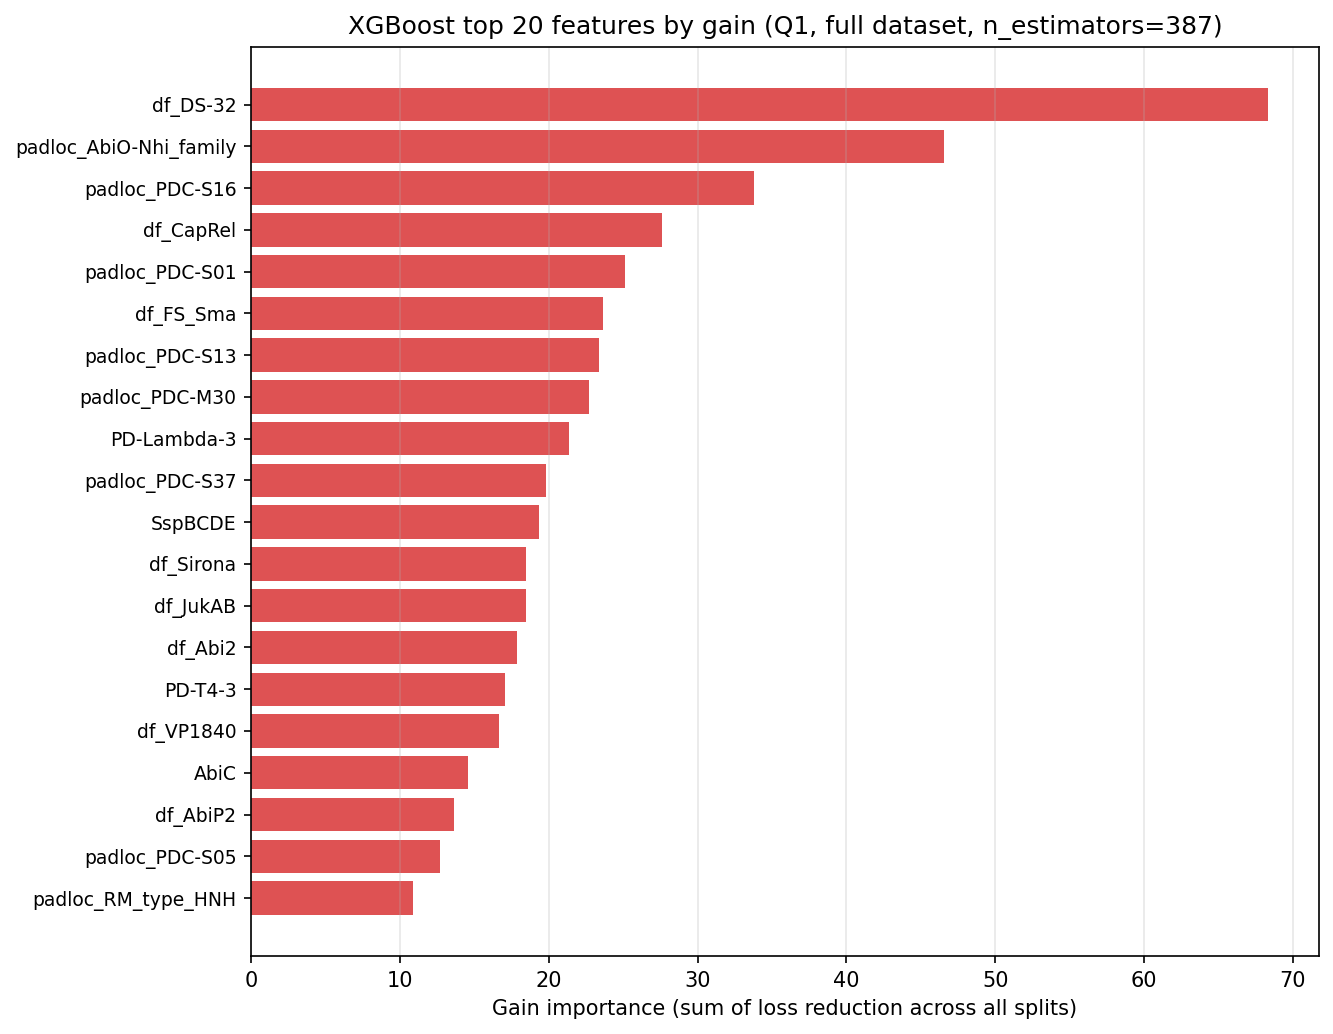


Top 20 features by XGBoost gain importance:
  Feature                                        Gain
  ----------------------------------------------------
  df_DS-32                                       68.3
  padloc_AbiO-Nhi_family                         46.6
  padloc_PDC-S16                                 33.8
  df_CapRel                                      27.6
  padloc_PDC-S01                                 25.1
  df_FS_Sma                                      23.7
  padloc_PDC-S13                                 23.4
  padloc_PDC-M30                                 22.7
  PD-Lambda-3                                    21.4
  padloc_PDC-S37                                 19.8
  SspBCDE                                        19.3
  df_Sirona                                      18.5
  df_JukAB                                       18.5
  df_Abi2                                        17.8
  PD-T4-3                                        17.1
  df_VP1840                         

In [11]:
# Train on full dataset  -  best params + median n_estimators from Section 7
sw_full = compute_sample_weight("balanced", y_q1)
xgb_imp = XGBClassifier(
    **best_params_xgb,
    n_estimators     = int(np.median(best_iters)),   # 387
    colsample_bytree = 0.8,
    verbosity        = 0,
    random_state     = RANDOM_STATE,
    n_jobs           = -1,
)
xgb_imp.fit(X, y_q1, sample_weight=sw_full)

# Gain scores keyed as "f0", "f1", ... — map back to feature names
gain_raw  = xgb_imp.get_booster().get_score(importance_type="gain")
idx_to_name = {f"f{i}": name for i, name in enumerate(FEAT_COLS)}
gain_named  = {idx_to_name.get(k, k): v for k, v in gain_raw.items()}
gain_series = pd.Series(gain_named).sort_values(ascending=False)

top_n   = 20
top_feat = gain_series.head(top_n)
labels  = [f.replace("dp_", "") for f in top_feat.index]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(range(top_n), top_feat.values[::-1], color="#d62728", alpha=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels(labels[::-1], fontsize=9)
ax.set_xlabel("Gain importance (sum of loss reduction across all splits)")
ax.set_title(f"XGBoost top {top_n} features by gain (Q1, full dataset, n_estimators=387)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()

gain_path = FIG / "q1_xgb_gain_importance.png"
fig.savefig(gain_path, dpi=150, bbox_inches="tight")
plt.close()
display(IPImage(filename=str(gain_path)))

print(f"\nTop {top_n} features by XGBoost gain importance:")
print(f"  {'Feature':<40} {'Gain':>10}")
print("  " + "-" * 52)
for feat, val in top_feat.items():
    print(f"  {feat.replace('dp_', ''):<40} {val:>10.1f}")

print(f"\nFeatures with non-zero gain: {len(gain_series)} / {len(FEAT_COLS)}")
print(f"Features never split on:     {len(FEAT_COLS) - len(gain_series)}")

## Section 10  -  Q2: XGBoost and LightGBM for ARG burden prediction (per species)

**Context from NB06 (RF Q2, AUROC-based significance):**
RF was significant in 4/6 species: EC (AUROC=0.765), KP (AUROC=0.822),
PA (AUROC=0.782), EF (AUROC=0.739). AB and SA were non-significant.

**What this section does:**
Re-runs the Q2 task with XGBoost and LightGBM and compares balanced accuracy
across all four models (LR, RF, XGB, LGBM). Note: NB06 used AUROC as the
significance metric; this table uses balanced accuracy for direct cross-model
comparison. Significance testing for XGBoost is formalised in Section 10b.

**What to look for:**
- EC and KP: do boosted models improve on RF (the current best for these species)?
- EF: RF BA=0.635 was the best in NB06. Does boosting close that further?
- SA: consistently non-significant across all models — consistent with chromosomal
  rather than defence-linked resistance in this species.

In [12]:
results_q2_xgb  = {}
results_q2_lgbm = {}
ba_xgb_dict     = {}  # fold-level XGB BAs per species, used for BH correction in S10b

for sp in sorted(fm["species"].unique()):
    sp_mask  = fm["species"].to_numpy(dtype=str) == sp
    fm_sp    = fm[sp_mask]

    # Q2 labels: top vs bottom ARG burden tertile only (mid-tertile excluded)
    mask_q2 = fm_sp["arg_burden_tertile"].isin(["low_ARG", "high_ARG"])
    fm_q2   = fm_sp[mask_q2]
    if len(fm_q2) < 20 or fm_q2["arg_burden_tertile"].nunique() < 2:
        print(f"  {sp}: insufficient Q2 data -- skip")
        continue
    y_sp   = (fm_q2["arg_burden_tertile"] == "high_ARG").astype(int).values
    # Per-species sparsity filter: keep only features with >=5% prevalence in this species
    feat_prev_sp = fm_q2[FEAT_COLS].mean()
    feat_q2_sp   = feat_prev_sp[feat_prev_sp >= 0.05].index.tolist()
    X_sp         = fm_q2[feat_q2_sp].values
    grp_sp = fm_q2["phylogroup"].to_numpy(dtype=str)
    print(f"  {sp}: {len(feat_q2_sp)} features after sparsity filter (from {len(FEAT_COLS)})")

    cv_sp = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    for model_name, results_dict in [("xgb", results_q2_xgb), ("lgbm", results_q2_lgbm)]:
        ba_sp, auc_sp = [], []
        all_yt_sp, all_yp_sp = [], []

        for tr, te in cv_sp.split(X_sp, y_sp, groups=grp_sp):
            if len(set(y_sp[te])) < 2:
                continue

            inner_ss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
            tr_rel, val_rel = next(inner_ss.split(X_sp[tr], y_sp[tr]))
            tr_i  = tr[tr_rel]
            val_i = tr[val_rel]
            sw_i  = compute_sample_weight("balanced", y_sp[tr_i])

            if model_name == "xgb":
                m = XGBClassifier(
                    **best_params_xgb,
                    n_estimators=300, early_stopping_rounds=20,
                    colsample_bytree=0.8, eval_metric="logloss",
                    verbosity=0, random_state=RANDOM_STATE, n_jobs=-1,
                )
                m.fit(X_sp[tr_i], y_sp[tr_i], sample_weight=sw_i,
                      eval_set=[(X_sp[val_i], y_sp[val_i])], verbose=False)
            else:
                m = LGBMClassifier(
                    **{k: v for k, v in lgbm_params.items() if k != "n_estimators"},
                    n_estimators=300,
                )
                m.fit(X_sp[tr_i], y_sp[tr_i],
                      eval_set=[(X_sp[val_i], y_sp[val_i])],
                      callbacks=[lgb.early_stopping(20, verbose=False),
                                 lgb.log_evaluation(-1)])

            pred  = m.predict(X_sp[te])
            prob  = m.predict_proba(X_sp[te])[:, 1]
            all_yt_sp.extend(y_sp[te])
            all_yp_sp.extend(pred)
            ba_sp.append(balanced_accuracy_score(y_sp[te], pred))
            auc_sp.append(roc_auc_score(y_sp[te], prob))

        if not ba_sp:
            continue
        if model_name == "xgb":
            ba_xgb_dict[sp] = list(ba_sp)
        mean_ba_sp, lo_sp, hi_sp = bootstrap_ci(np.array(all_yt_sp), np.array(all_yp_sp))
        results_dict[sp] = {"ba": mean_ba_sp, "lo": lo_sp, "hi": hi_sp,
                            "auroc": np.mean(auc_sp)}

# Load LR and RF Q2 results for comparison table
lr_q2 = {"ecloaceae":0.752,"kpneumoniae":0.719,"paeruginosa":0.645,
          "efaecium":0.512,"saureus":0.470,"abaumannii":0.473}
_rf_df = pd.read_parquet(RES / "q2_rf_results_3460.parquet")
rf_q2  = dict(zip(_rf_df["species"], _rf_df["ba"]))

print(f"\nQ2 comparison (balanced accuracy):")
print(f"  {'Species':<22} {'LR':>6}  {'RF':>6}  {'XGB':>6}  {'LGBM':>6}  Winner")
print("  " + "-" * 68)
for sp in sorted(results_q2_xgb.keys()):
    lrv = lr_q2.get(sp, float("nan"))
    rfv = rf_q2.get(sp, float("nan"))
    xv  = results_q2_xgb.get(sp, {}).get("ba", float("nan"))
    lv  = results_q2_lgbm.get(sp, {}).get("ba", float("nan"))
    winner = max(["LR", "RF", "XGB", "LGBM"],
                 key=lambda m: {"LR": lrv, "RF": rfv, "XGB": xv, "LGBM": lv}[m])
    print(f"  {sp:<22} {lrv:.3f}  {rfv:.3f}  {xv:.3f}  {lv:.3f}  {winner}")

  abaumannii: 36 features after sparsity filter (from 359)


  ecloaceae: 62 features after sparsity filter (from 359)


  efaecium: 23 features after sparsity filter (from 359)


  kpneumoniae: 85 features after sparsity filter (from 359)


  paeruginosa: 65 features after sparsity filter (from 359)


  saureus: 25 features after sparsity filter (from 359)



Q2 comparison (balanced accuracy):
  Species                    LR      RF     XGB    LGBM  Winner
  --------------------------------------------------------------------
  abaumannii             0.473  0.490  0.633  0.588  XGB
  ecloaceae              0.752  0.681  0.654  0.637  LR
  efaecium               0.512  0.635  0.594  0.582  RF
  kpneumoniae            0.719  0.687  0.706  0.698  LR
  paeruginosa            0.645  0.664  0.682  0.683  LGBM
  saureus                0.470  0.611  0.543  0.478  RF


## Section 10b  -  BH correction across Q2 species (XGBoost)

**Why BH correction is required:**
We run one significance test per species (6 tests total against a BA=0.5 null).
Without correction, the expected number of false positives at α=0.05 is 0.3 — low
but non-zero. BH correction controls the false discovery rate across the 6 species,
ensuring that any species flagged as significant survives multiple testing scrutiny.

**Method:** One-sample t-test per species (XGBoost fold BAs vs null BA=0.5),
then BH correction across all 6 species. n_folds reported for transparency.

In [13]:
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import multipletests

null_ba  = 0.5
sp_order = sorted(ba_xgb_dict.keys())
p_raw    = []
for sp in sp_order:
    ba_list = ba_xgb_dict[sp]
    if len(ba_list) >= 2:
        _, pval = ttest_1samp(ba_list, popmean=null_ba, alternative="greater")
        p_raw.append(pval)
    else:
        p_raw.append(float("nan"))

valid_idx   = [i for i, p in enumerate(p_raw) if not (p != p)]
sp_valid    = [sp_order[i] for i in valid_idx]
pvals_valid = [p_raw[i]    for i in valid_idx]

reject_bh, pvals_adj, _, _ = multipletests(pvals_valid, alpha=0.05, method="fdr_bh")
q2_pval_map_xgb = dict(zip(sp_valid, pvals_adj))
q2_praw_map_xgb = dict(zip(sp_valid, pvals_valid))
q2_sig_map_xgb  = dict(zip(sp_valid, reject_bh))

print("Q2 XGBoost null-baseline significance (one-sample t vs BA=0.5, BH-corrected):")
print(f"  {'Species':<22} {'XGB BA':>7}  {'n_folds':>7}  {'p_raw':>8}  {'p_adj_BH':>10}  {'Sig?':>5}")
print("  " + "-" * 72)
for sp in sp_order:
    ba_v = results_q2_xgb.get(sp, {}).get("ba", float("nan"))
    n_f  = len(ba_xgb_dict.get(sp, []))
    p_r  = q2_praw_map_xgb.get(sp, float("nan"))
    p_a  = q2_pval_map_xgb.get(sp, float("nan"))
    sig  = "YES" if q2_sig_map_xgb.get(sp, False) else "ns"
    print(f"  {sp:<22} {ba_v:.3f}   {n_f:>7}  {p_r:.4f}    {p_a:.4f}      {sig}")

Q2 XGBoost null-baseline significance (one-sample t vs BA=0.5, BH-corrected):
  Species                 XGB BA  n_folds     p_raw    p_adj_BH   Sig?
  ------------------------------------------------------------------------
  abaumannii             0.633         5  0.0289    0.0347      YES
  ecloaceae              0.654         5  0.0011    0.0068      YES
  efaecium               0.594         5  0.0163    0.0244      YES
  kpneumoniae            0.706         5  0.0073    0.0146      YES
  paeruginosa            0.682         5  0.0048    0.0143      YES
  saureus                0.543         5  0.2152    0.2152      ns


## Section 10c  -  McNemar tests for Q2 per-species model comparisons

**Why point-estimate BA differences are not enough:**
With per-species n ~60–100 genomes in the test set per fold, a BA difference of 0.02
could easily be noise. McNemar's test uses the paired per-genome predictions to ask
whether two models are making errors on the same genomes (no real difference) or
systematically different ones (real difference).

**Approach:** Re-run all four models (LR, RF, XGB, LGBM) on the same
StratifiedGroupKFold splits per species, collecting aligned per-genome predictions.
Pairwise McNemar tests per species: LR vs RF, LR vs XGB, LR vs LGBM, RF vs XGB.
The same per-species sparsity filter (≥5% prevalence) is applied throughout.

In [14]:
from sklearn.linear_model import LogisticRegression as LR_cls
from sklearn.ensemble import RandomForestClassifier as RF_cls

mc_q2 = {}  # sp -> {model_name: pred_array, "y_true": array}

for sp in sorted(fm["species"].unique()):
    sp_mask = fm["species"].to_numpy(dtype=str) == sp
    fm_sp   = fm[sp_mask]
    mask_q2 = fm_sp["arg_burden_tertile"].isin(["low_ARG", "high_ARG"])
    fm_q2   = fm_sp[mask_q2]
    if len(fm_q2) < 20 or fm_q2["arg_burden_tertile"].nunique() < 2:
        continue
    y_sp   = (fm_q2["arg_burden_tertile"] == "high_ARG").astype(int).values

    feat_prev_sp = fm_q2[FEAT_COLS].mean()
    feat_q2_sp   = feat_prev_sp[feat_prev_sp >= 0.05].index.tolist()
    X_sp         = fm_q2[feat_q2_sp].values
    grp_sp       = fm_q2["phylogroup"].to_numpy(dtype=str)
    cv_sp        = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True,
                                        random_state=RANDOM_STATE)

    n_sp = len(y_sp)
    # sentinel -1 for genomes never in a valid test fold
    preds  = {m: np.full(n_sp, -1, dtype=int)
              for m in ["lr", "rf", "xgb", "lgbm"]}
    y_true = np.full(n_sp, -1, dtype=int)

    for tr, te in cv_sp.split(X_sp, y_sp, groups=grp_sp):
        if len(set(y_sp[te])) < 2:
            continue
        y_true[te] = y_sp[te]

        # LR
        lr_m = LR_cls(max_iter=1000, class_weight="balanced",
                      C=0.1, solver="saga", random_state=RANDOM_STATE)
        lr_m.fit(X_sp[tr], y_sp[tr])
        preds["lr"][te] = lr_m.predict(X_sp[te])

        # RF -- extract params from saved model (best_params not in GB scope)
        rf_q2_params = {k: v for k, v in rf_best.get_params().items()
                        if k in ["n_estimators", "max_depth", "min_samples_leaf",
                                 "max_features", "random_state", "n_jobs"]}
        rf_m = RF_cls(**rf_q2_params, class_weight="balanced")
        rf_m.fit(X_sp[tr], y_sp[tr])
        preds["rf"][te] = rf_m.predict(X_sp[te])

        # XGB + LGBM share inner split
        inner_ss = StratifiedShuffleSplit(n_splits=1, test_size=0.2,
                                          random_state=RANDOM_STATE)
        tr_rel, val_rel = next(inner_ss.split(X_sp[tr], y_sp[tr]))
        tr_i, val_i = tr[tr_rel], tr[val_rel]
        sw_i = compute_sample_weight("balanced", y_sp[tr_i])

        xgb_m = XGBClassifier(**best_params_xgb, n_estimators=300,
                               early_stopping_rounds=20, colsample_bytree=0.8,
                               eval_metric="logloss", verbosity=0,
                               random_state=RANDOM_STATE, n_jobs=-1)
        xgb_m.fit(X_sp[tr_i], y_sp[tr_i], sample_weight=sw_i,
                  eval_set=[(X_sp[val_i], y_sp[val_i])], verbose=False)
        preds["xgb"][te] = xgb_m.predict(X_sp[te])

        lgbm_m = LGBMClassifier(
            **{k: v for k, v in lgbm_params.items() if k != "n_estimators"},
            n_estimators=300)
        lgbm_m.fit(X_sp[tr_i], y_sp[tr_i],
                   eval_set=[(X_sp[val_i], y_sp[val_i])],
                   callbacks=[lgb.early_stopping(20, verbose=False),
                               lgb.log_evaluation(-1)])
        preds["lgbm"][te] = lgbm_m.predict(X_sp[te])

    mask = y_true >= 0
    if mask.sum() < 10:
        continue
    yt = y_true[mask]
    mc_q2[sp] = {"y_true": yt}
    for m in ["lr", "rf", "xgb", "lgbm"]:
        mc_q2[sp][m] = preds[m][mask]

    bas = {m: balanced_accuracy_score(yt, mc_q2[sp][m]) for m in ["lr", "rf", "xgb", "lgbm"]}
    print(f"\n{sp} (n={mask.sum()}):")
    print(f"  {'Model':<8}  BA")
    for m in ["lr", "rf", "xgb", "lgbm"]:
        print(f"  {m.upper():<8}  {bas[m]:.3f}")

    pairs = [("LR", "RF"), ("LR", "XGB"), ("LR", "LGBM"), ("RF", "XGB")]
    print(f"  {'Comparison':<16}  {'delta':>6}  {'b':>4}  {'c':>4}  {'p':>7}  Sig?")
    print("  " + "-" * 52)
    for ma, mb in pairs:
        p, b, c, _ = mcnemar_test(yt, mc_q2[sp][ma.lower()], mc_q2[sp][mb.lower()])
        delta = bas[ma.lower()] - bas[mb.lower()]
        sig = "*" if p < 0.05 else "ns"
        print(f"  {ma + ' vs ' + mb:<16}  {delta:+.3f}   {b:>4}  {c:>4}  {p:.4f}  {sig}")



abaumannii (n=419):
  Model     BA
  LR        0.579
  RF        0.490
  XGB       0.633
  LGBM      0.588
  Comparison         delta     b     c        p  Sig?
  ----------------------------------------------------
  LR vs RF          +0.088     41     7  0.0000  *
  LR vs XGB         -0.054     21    39  0.0282  *
  LR vs LGBM        -0.009     27    28  1.0000  ns
  RF vs XGB         -0.142     13    65  0.0000  *



ecloaceae (n=372):
  Model     BA
  LR        0.700
  RF        0.681
  XGB       0.654
  LGBM      0.637
  Comparison         delta     b     c        p  Sig?
  ----------------------------------------------------
  LR vs RF          +0.018     31    31  0.8989  ns
  LR vs XGB         +0.046     38    21  0.0372  *
  LR vs LGBM        +0.063     43    19  0.0035  *
  RF vs XGB         +0.027     39    22  0.0405  *



efaecium (n=365):
  Model     BA
  LR        0.574
  RF        0.635
  XGB       0.594
  LGBM      0.582
  Comparison         delta     b     c        p  Sig?
  ----------------------------------------------------
  LR vs RF          -0.061     33    56  0.0197  *
  LR vs XGB         -0.020     26    34  0.3662  ns
  LR vs LGBM        -0.008     17    20  0.7423  ns
  RF vs XGB         +0.041     40    25  0.0825  ns



kpneumoniae (n=331):
  Model     BA
  LR        0.702
  RF        0.687
  XGB       0.706
  LGBM      0.698
  Comparison         delta     b     c        p  Sig?
  ----------------------------------------------------
  LR vs RF          +0.014     20    17  0.7423  ns
  LR vs XGB         -0.004     23    23  0.8828  ns
  LR vs LGBM        +0.003     19    17  0.8676  ns
  RF vs XGB         -0.019     26    29  0.7874  ns



paeruginosa (n=471):
  Model     BA
  LR        0.680
  RF        0.664
  XGB       0.682
  LGBM      0.683
  Comparison         delta     b     c        p  Sig?
  ----------------------------------------------------
  LR vs RF          +0.016     31    30  1.0000  ns
  LR vs XGB         -0.003     31    34  0.8041  ns
  LR vs LGBM        -0.003     32    36  0.7160  ns
  RF vs XGB         -0.018     30    34  0.7077  ns



saureus (n=449):
  Model     BA
  LR        0.518
  RF        0.611
  XGB       0.543
  LGBM      0.478
  Comparison         delta     b     c        p  Sig?
  ----------------------------------------------------
  LR vs RF          -0.093     35    74  0.0003  *
  LR vs XGB         -0.025     38    49  0.2837  ns
  LR vs LGBM        +0.040     57    49  0.4966  ns
  RF vs XGB         +0.068     32     4  0.0000  *


## Section 11  -  Save results

In [15]:
# Q1 summary
q1_gb = pd.DataFrame([
    {"model": "XGBoost", "ba_mean": mean_ba_xgb, "ba_lo": lo_xgb, "ba_hi": hi_xgb,
     "f1_mean": mean_f1_xgb, "cv": "GroupedStratifiedKFold_5",
     "early_stopping": True, "median_best_iter": int(np.median(best_iters)),
     **{f"param_{k}": v for k, v in best_params_xgb.items()}},
    {"model": "LightGBM", "ba_mean": mean_ba_lgbm, "ba_lo": lo_lgbm, "ba_hi": hi_lgbm,
     "f1_mean": mean_f1_lgbm, "cv": "GroupedStratifiedKFold_5",
     "early_stopping": True, "median_best_iter": int(np.median(best_iters_lgbm)),
     "param_num_leaves": 63, **{f"param_{k}": v for k, v in lgbm_params.items()
                                if k in ["learning_rate", "max_depth", "subsample"]}},
])
q1_gb.to_parquet(RES / "q1_gb_results_3460.parquet")
print("Saved: results/q1_gb_results.parquet")

# Q2 summary (including H4 BH-corrected p-values for XGB)
q2_rows = []
for sp, vals in results_q2_xgb.items():
    q2_rows.append({"species": sp, "model": "XGBoost",
                    "p_adj_bh": q2_pval_map_xgb.get(sp, float("nan")),
                    "p_raw":    q2_praw_map_xgb.get(sp, float("nan")),
                    "sig_bh":   q2_sig_map_xgb.get(sp, False),
                    **vals})
for sp, vals in results_q2_lgbm.items():
    q2_rows.append({"species": sp, "model": "LightGBM", **vals})
pd.DataFrame(q2_rows).to_parquet(RES / "q2_gb_results_3460.parquet")
print("Saved: results/q2_gb_results.parquet")

# Per-genome prediction arrays for Phase 10 McNemar (if needed)
np.save(RES / "mc_pred_xgb_q1.npy", mc_pred_xgb)
np.save(RES / "mc_pred_lgbm_q1.npy", mc_pred_lgbm)
np.save(RES / "mc_pred_rf_q1.npy",   mc_pred_rf)
np.save(RES / "mc_true_q1.npy",      mc_true_xgb)   # same genome ordering
print("Saved: McNemar prediction arrays (results/mc_pred_*.npy)")

print("\nAll outputs saved.")


Saved: results/q1_gb_results.parquet
Saved: results/q2_gb_results.parquet
Saved: McNemar prediction arrays (results/mc_pred_*.npy)

All outputs saved.
